# Evaluation — llama3.3:70b

Compares `llama3.3-70b` LLM predictions against manually labeled ground truth (`data/manuallabeled/*_dmp.json`).

Sections:
1. Load samples & accuracy table
2. Per-sample accuracy chart
3. Confusion matrix
4. Precision / Recall / F1 per label
5. Mislabeled blocks
6. Ablation — effect of smoothing rules

## Setup

In [1]:
MODEL_NAME  = "llama3.3:70b"
MODEL_BASE  = "llama3.3-70b"
MODEL_TAG   = MODEL_BASE + "-nosmooth"    # data/llmlabeled/sample*_llama3.3-70b-nosmooth.json
MODEL_COLOR = "#2563eb"

In [2]:
import sys
sys.path.insert(0, "..")

from evaluate import extract_gold, evaluate_sample, match, LABELS, SHORT, LLM_DIR, MANUAL_DIR, NO_MATCH
import json
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# Publication style
sns.set_theme(style="ticks", palette="muted")
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "axes.edgecolor":"#555555","axes.linewidth":0.8,
    "grid.color":"#dddddd","grid.linewidth":0.5,
    "text.color":"#111111","axes.labelcolor":"#111111",
    "xtick.color":"#111111","ytick.color":"#111111",
    "font.size":11,"axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,
    "legend.fontsize":10,"legend.frameon":True,"legend.edgecolor":"#cccccc",
    "figure.dpi":120,
})

def _snum(name):
    s = name.stem if hasattr(name,"stem") else name
    return int(s.replace("_dmp","").replace("sample",""))

print(f"Ready — model: {MODEL_NAME}  tag: {MODEL_TAG}")


Ready — model: llama3.3:70b  tag: llama3.3-70b-nosmooth


## 1 — Load samples & accuracy table

In [3]:
samples = sorted(MANUAL_DIR.glob("*_dmp.json"), key=_snum)
conf_all = defaultdict(lambda: defaultdict(int))
per_sample_rows, all_errors = [], []

for mp in samples:
    stem = mp.stem.replace("_dmp", "")
    pp   = LLM_DIR / f"{stem}_{MODEL_TAG}.json"
    if not pp.exists():
        print(f"  MISSING: {pp.name}"); continue
    gold = extract_gold(mp)
    conf = evaluate_sample(pp, gold)
    blocks = json.loads(pp.read_text(encoding="utf-8"))
    for block in blocks:
        tl = match(block["text"], gold)
        pl = block.get("label", "answer.text")
        key = tl if tl else NO_MATCH
        conf_all[key][pl] += 1
        if tl != pl:
            all_errors.append({"sample": stem, "text": block["text"][:120],
                                "true": tl or "no_match", "pred": pl,
                                "page": block.get("page", "-")})
    tp = sum(conf.get(l, {}).get(l, 0) for l in LABELS)
    n  = sum(sum(v.values()) for v in conf.values())
    per_sample_rows.append({"sample": stem, "total": n, "correct": tp,
                             "errors": n - tp, "accuracy": tp / n if n else 0,
                             "formula": f"{tp}/{n}"})

df     = pd.DataFrame(per_sample_rows)
df_err = pd.DataFrame(all_errors)

hdr = f"{'Sample':<12}  {'Total':>5}  {'Correct':>7}  {'Errors':>6}  {'Accuracy':>8}  Formula"
print(hdr); print("-" * len(hdr))
for row in df.itertuples():
    print(f"{row.sample:<12}  {row.total:>5}  {row.correct:>7}  {row.errors:>6}  {row.accuracy*100:>7.1f}%  {row.formula}")
print("-" * len(hdr))
tn, tc = df["total"].sum(), df["correct"].sum()
print(f"{'TOTAL':<12}  {tn:>5}  {tc:>7}  {tn-tc:>6}  {tc/tn*100:>7.1f}%  {tc}/{tn}")


Sample        Total  Correct  Errors  Accuracy  Formula
-------------------------------------------------------
sample1          78       76       2     97.4%  76/78
sample2         171      156      15     91.2%  156/171
sample3          69       68       1     98.6%  68/69
sample4          78       78       0    100.0%  78/78
sample5          80       79       1     98.8%  79/80
sample6          24       18       6     75.0%  18/24
sample7          17       16       1     94.1%  16/17
sample8          59       57       2     96.6%  57/59
sample9          85       84       1     98.8%  84/85
sample10         68       65       3     95.6%  65/68
-------------------------------------------------------
TOTAL           729      697      32     95.6%  697/729


## 2 — Per-sample accuracy

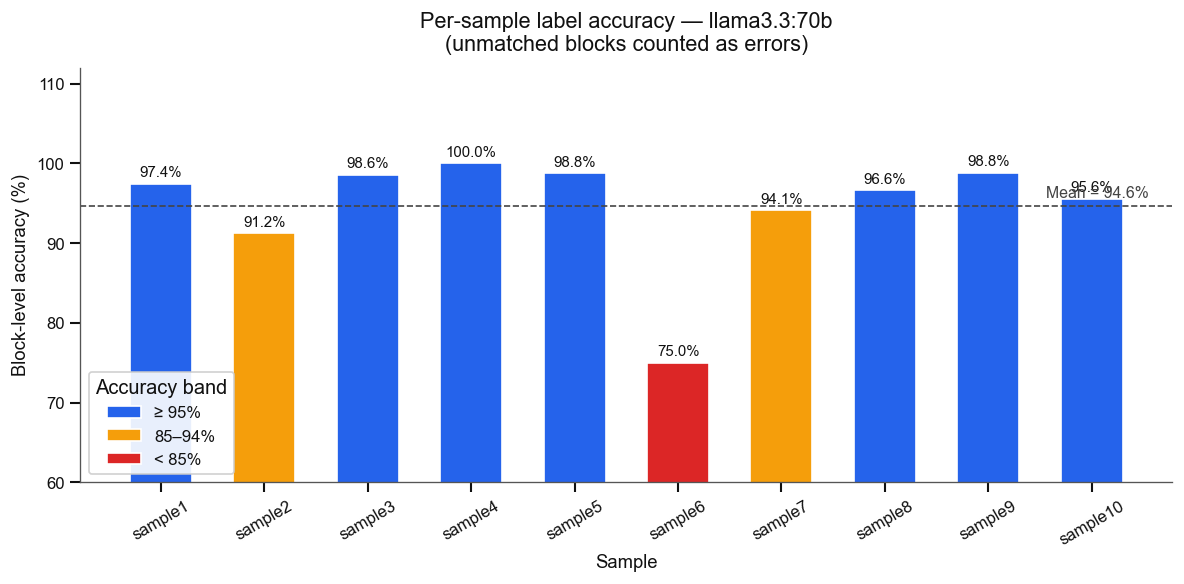

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2563eb" if a >= 0.95 else "#f59e0b" if a >= 0.85 else "#dc2626"
          for a in df["accuracy"]]
bars = ax.bar(df["sample"], df["accuracy"] * 100,
              color=colors, width=0.6, edgecolor="white")
for bar, acc in zip(bars, df["accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=9)
avg = df["accuracy"].mean() * 100
ax.axhline(avg, color="#444444", linestyle="--", linewidth=1.0)
ax.text(len(df) - 0.45, avg + 0.7, f"Mean = {avg:.1f}%",
        ha="right", va="bottom", fontsize=9.5, color="#444444")
ax.set_ylim(60, 112)
ax.set_ylabel("Block-level accuracy (%)")
ax.set_xlabel("Sample")
ax.set_title(f"Per-sample label accuracy — {MODEL_NAME}\n(unmatched blocks counted as errors)", pad=10)
ax.tick_params(axis="x", rotation=30)
legend_h = [mpatches.Patch(facecolor="#2563eb", label="≥ 95%"),
            mpatches.Patch(facecolor="#f59e0b", label="85–94%"),
            mpatches.Patch(facecolor="#dc2626", label="< 85%")]
ax.legend(handles=legend_h, title="Accuracy band", loc="lower left", framealpha=0.9)
sns.despine(); plt.tight_layout(); plt.show()


## 3 — Confusion matrix (all samples combined)

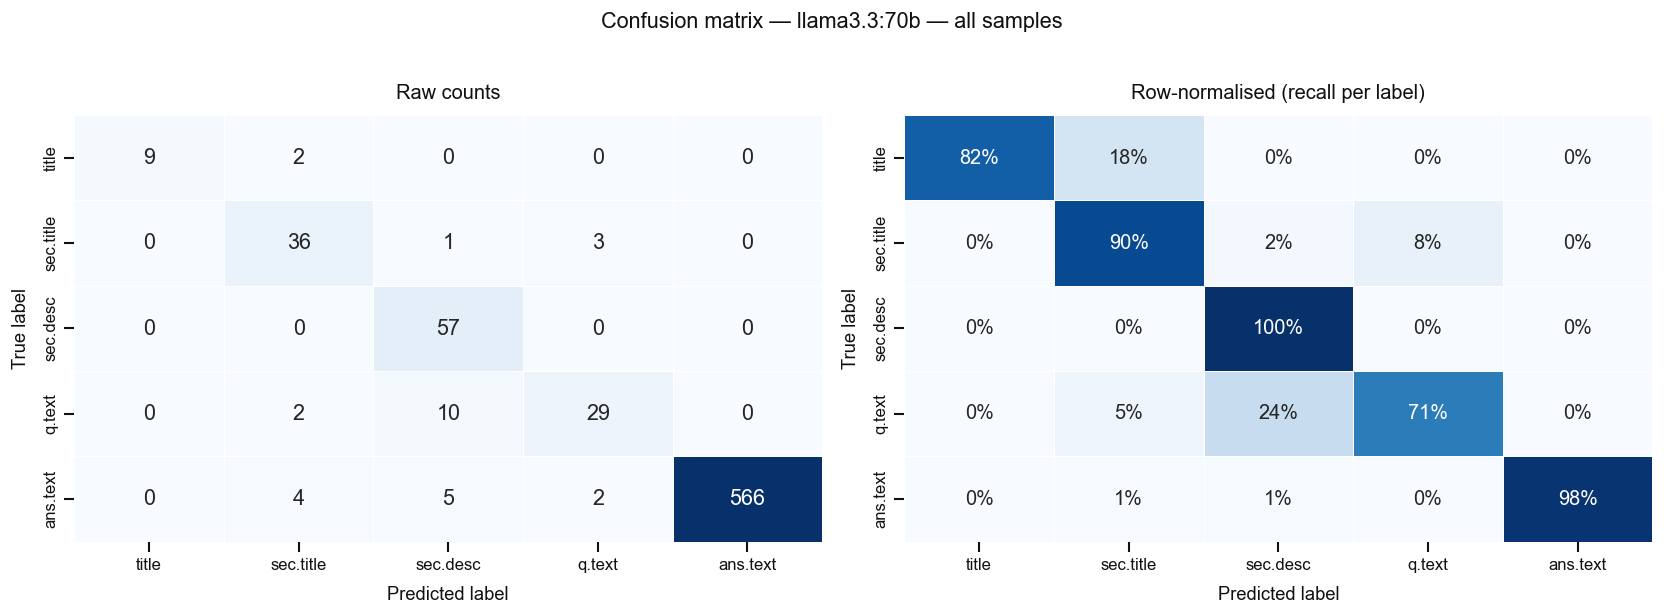

In [5]:
matrix = pd.DataFrame(
    [[conf_all.get(t,{}).get(p,0) for p in LABELS] for t in LABELS],
    index=SHORT, columns=SHORT)
matrix_norm = matrix.div(matrix.sum(axis=1).replace(0,1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", linewidths=0.6,
            linecolor="white", ax=axes[0], cbar=False, annot_kws={"size":13})
axes[0].set_title("Raw counts", pad=10, fontsize=12)
axes[0].set_xlabel("Predicted label", labelpad=8)
axes[0].set_ylabel("True label", labelpad=8)
sns.heatmap(matrix_norm, annot=True, fmt=".0%", cmap="Blues", linewidths=0.6,
            linecolor="white", ax=axes[1], cbar=False, vmin=0, vmax=1,
            annot_kws={"size":12})
axes[1].set_title("Row-normalised (recall per label)", pad=10, fontsize=12)
axes[1].set_xlabel("Predicted label", labelpad=8)
axes[1].set_ylabel("True label", labelpad=8)
plt.suptitle(f"Confusion matrix — {MODEL_NAME} — all samples", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


## 4 — Precision / Recall / F1 per label

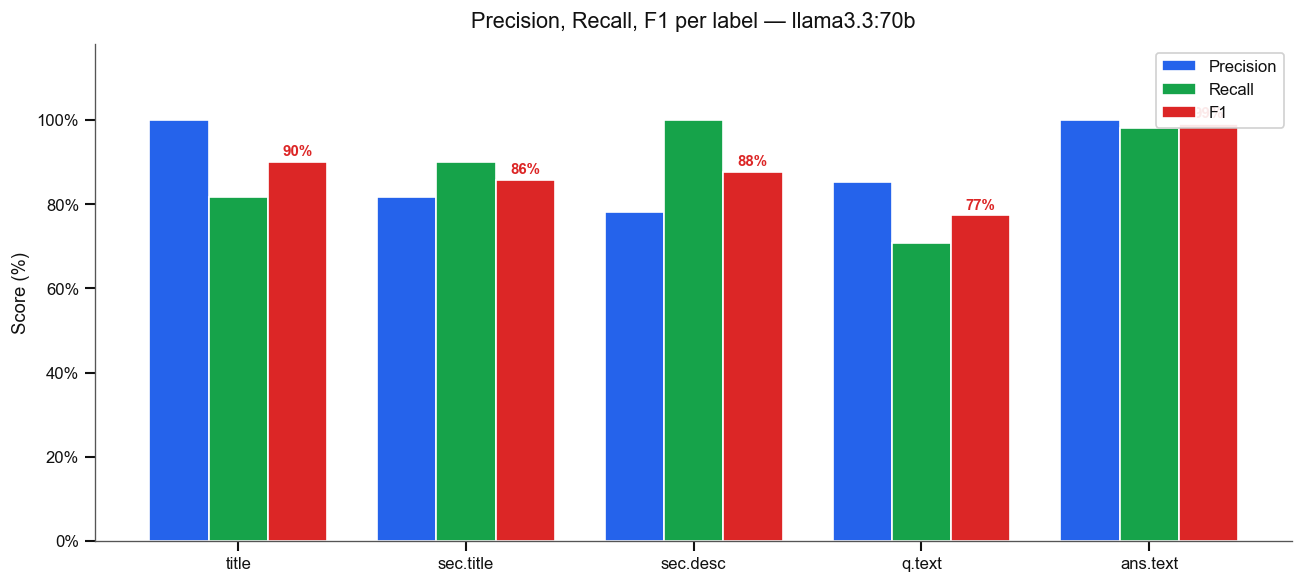

,precision,recall,f1,support
label,,,,
title,100.0%,81.8%,90.0%,11
section.title,81.8%,90.0%,85.7%,40
section.description,78.1%,100.0%,87.7%,57
question.text,85.3%,70.7%,77.3%,41
answer.text,100.0%,98.1%,99.0%,577


In [6]:
f1_rows = []
for lbl in LABELS:
    tp = conf_all.get(lbl,{}).get(lbl,0)
    fp = sum(conf_all.get(o,{}).get(lbl,0) for o in LABELS if o!=lbl)
    fn = sum(v for p,v in conf_all.get(lbl,{}).items() if p!=lbl)
    support = tp+fn
    p_  = tp/(tp+fp) if (tp+fp) else 0.
    r_  = tp/support if support else 0.
    f1  = 2*p_*r_/(p_+r_) if (p_+r_) else 0.
    f1_rows.append({"label":lbl,"precision":p_,"recall":r_,"f1":f1,"support":support})
df_f1 = pd.DataFrame(f1_rows)

x, w = range(len(LABELS)), 0.26
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar([i-w for i in x], df_f1["precision"]*100, width=w, label="Precision",
            color="#2563eb", edgecolor="white")
b2 = ax.bar([i   for i in x], df_f1["recall"]*100,    width=w, label="Recall",
            color="#16a34a", edgecolor="white")
b3 = ax.bar([i+w for i in x], df_f1["f1"]*100,        width=w, label="F1",
            color="#dc2626", edgecolor="white")
for bar, row in zip(b3, df_f1.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{row.f1*100:.0f}%", ha="center", va="bottom",
            fontsize=9, fontweight="bold", color="#dc2626")
ax.set_xticks(list(x)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 118); ax.set_ylabel("Score (%)")
ax.set_title(f"Precision, Recall, F1 per label — {MODEL_NAME}", pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(loc="upper right", framealpha=0.9)
sns.despine(); plt.tight_layout(); plt.show()

df_f1.set_index("label").style.format(
    {"precision":"{:.1%}","recall":"{:.1%}","f1":"{:.1%}","support":"{:.0f}"})


## 5 — Mislabeled blocks

In [7]:
if df_err.empty:
    print("No errors — perfect score!")
else:
    print(f"{len(df_err)} mislabeled blocks\n")
    breakdown = (df_err.groupby(["true","pred"]).size()
                 .reset_index(name="count")
                 .sort_values("count", ascending=False))
    print(breakdown.to_string(index=False))


32 mislabeled blocks

         true                pred  count
question.text section.description     10
  answer.text section.description      5
  answer.text       section.title      4
section.title       question.text      3
     no_match       section.title      3
  answer.text       question.text      2
question.text       section.title      2
        title       section.title      2
section.title section.description      1


In [8]:
if not df_err.empty:
    pd.set_option("display.max_colwidth", 100)
    display(df_err[["sample","page","true","pred","text"]])


,sample,page,true,pred,text
0,sample1,1,answer.text,question.text,The following data will be created as a result of this project:
1,sample1,2,question.text,section.title,"Protections for privacy, rights, and confidentiality of human research participants:"
2,sample2,1,question.text,section.description,the course of the proposed research and which of these are considered Digital Research Data
3,sample2,1,question.text,section.description,necessary to Validate the research findings.
4,sample2,1,question.text,section.description,"applicable, a description of documentation plans, annotation of relevant software, and the ratio..."
5,sample2,1,question.text,section.description,"the selection of appropriate standards. (Existing, accepted community standards should be used w..."
6,sample2,1,question.text,section.description,"possible. Where community standards are missing or inadequate, the DMP could propose alternate"
7,sample2,1,question.text,section.description,"strategies that facilitate data sharing, and should advise the sponsoring program of any need to"
8,sample2,1,question.text,section.description,develop or generalize standards.)
9,sample2,2,question.text,section.title,Data Sharing and Data Preservation. A description of the plans for data sharing and preservation.


## 6 — Ablation: smoothing rules contribution

Compares current output (with rules) against `*-smooth.json` produced by `dmpbridge sample.pdf --smooth`.  
Solid bars = with rules. Hatched bars = no rules.

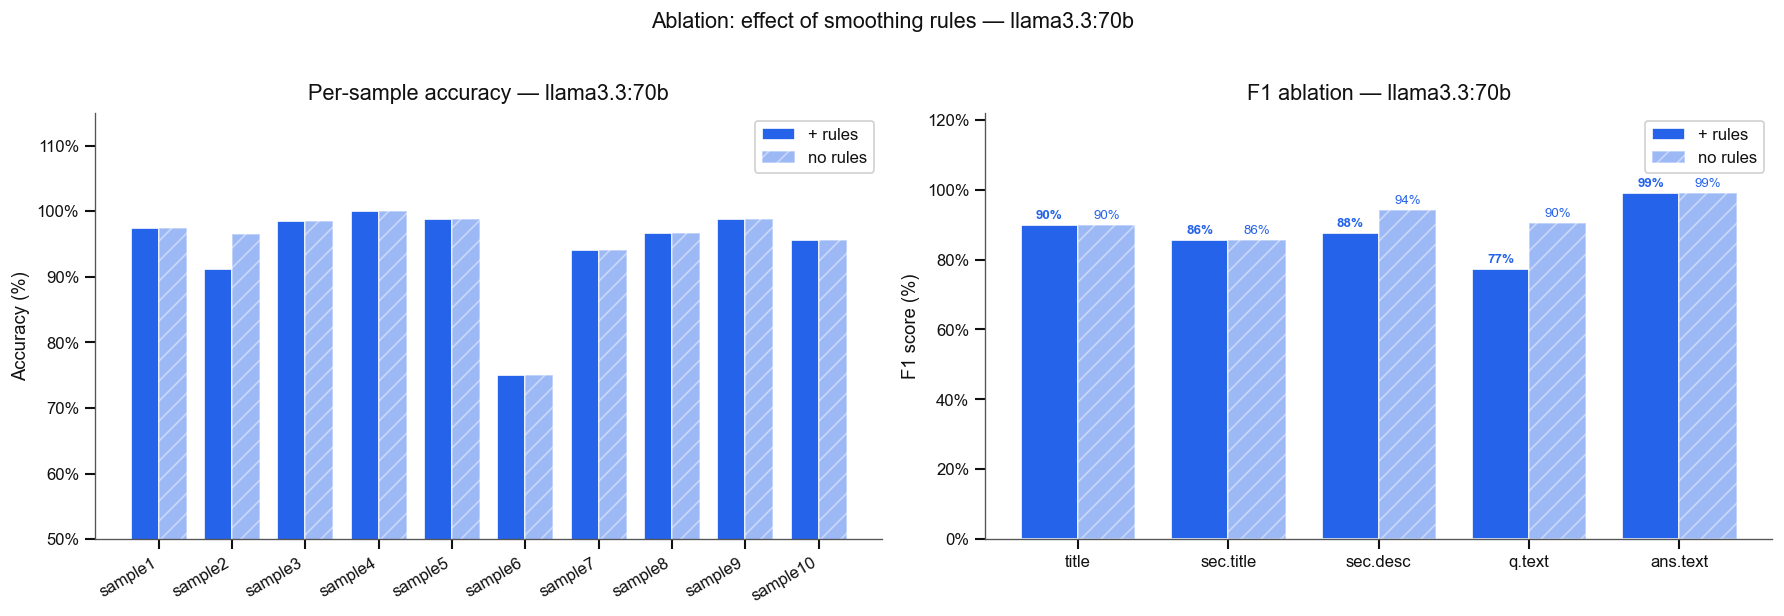


Label                     + rules   no rules     Gain
----------------------------------------------------
title                       90.0%      90.0%  +  0.0%
section.title               85.7%      85.7%  +  0.0%
section.description         87.7%      94.2%   -6.5%
question.text               77.3%      90.5%  -13.1%
answer.text                 99.0%      99.0%  +  0.0%
----------------------------------------------------
OVERALL                     95.6%      96.8%   -1.2%


In [9]:
# Load no-rules variant for this model
ns_tag  = MODEL_BASE + "-smooth"
ns_conf = defaultdict(lambda: defaultdict(int))
ns_rows = []

for mp in samples:
    stem = mp.stem.replace("_dmp","")
    pp   = LLM_DIR / f"{stem}_{ns_tag}.json"
    if not pp.exists():
        print(f"  MISSING no-rules file: {pp.name}"); continue
    gold = extract_gold(mp)
    conf = evaluate_sample(pp, gold)
    for tl,preds in conf.items():
        for pl,cnt in preds.items(): ns_conf[tl][pl] += cnt
    tp = sum(conf.get(l,{}).get(l,0) for l in LABELS)
    n  = sum(sum(v.values()) for v in conf.values())
    ns_rows.append({"sample":stem,"total":n,"correct":tp,"accuracy":tp/n if n else 0})

df_ns = pd.DataFrame(ns_rows)

def _f1s(c):
    out = []
    for lbl in LABELS:
        tp=c.get(lbl,{}).get(lbl,0)
        fp=sum(c.get(o,{}).get(lbl,0) for o in LABELS if o!=lbl)
        fn=sum(v for p,v in c.get(lbl,{}).items() if p!=lbl)
        p_=tp/(tp+fp) if (tp+fp) else 0.
        r_=tp/(tp+fn) if (tp+fn) else 0.
        out.append(2*p_*r_/(p_+r_) if (p_+r_) else 0.)
    return out

f1_with = _f1s(conf_all)
f1_ns   = _f1s(ns_conf)

# Chart
x_labels = sorted(df["sample"].tolist(), key=_snum)
df_s  = df.set_index("sample").loc[x_labels].reset_index()
df_ns_s = df_ns.set_index("sample").loc[x_labels].reset_index() if not df_ns.empty else None

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: per-sample accuracy
ax = axes[0]
x, w = range(len(x_labels)), 0.38
bars_w  = ax.bar([i-w/2 for i in x], df_s["accuracy"]*100,
                 width=w, label="+ rules", color=MODEL_COLOR, edgecolor="white")
if df_ns_s is not None:
    bars_ns = ax.bar([i+w/2 for i in x], df_ns_s["accuracy"]*100,
                     width=w, label="no rules", color=MODEL_COLOR,
                     alpha=0.45, edgecolor="white", hatch="//")
ax.set_xticks(list(x)); ax.set_xticklabels(x_labels, rotation=30, ha="right")
ax.set_ylim(50, 115); ax.set_ylabel("Accuracy (%)")
ax.set_title(f"Per-sample accuracy — {MODEL_NAME}", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9); sns.despine(ax=ax)

# Right: F1 per label
ax = axes[1]
x2, w2 = range(len(LABELS)), 0.38
b1 = ax.bar([i-w2/2 for i in x2], [v*100 for v in f1_with],
            width=w2, label="+ rules", color=MODEL_COLOR, edgecolor="white")
b2 = ax.bar([i+w2/2 for i in x2], [v*100 for v in f1_ns],
            width=w2, label="no rules", color=MODEL_COLOR,
            alpha=0.45, edgecolor="white", hatch="//")
for bar,v in zip(b1,f1_with):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{v*100:.0f}%", ha="center", va="bottom", fontsize=8, fontweight="bold",color=MODEL_COLOR)
for bar,v in zip(b2,f1_ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{v*100:.0f}%", ha="center", va="bottom", fontsize=8, color=MODEL_COLOR)
ax.set_xticks(list(x2)); ax.set_xticklabels(SHORT, fontsize=10)
ax.set_ylim(0, 122); ax.set_ylabel("F1 score (%)")
ax.set_title(f"F1 ablation — {MODEL_NAME}", pad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
ax.legend(framealpha=0.9); sns.despine(ax=ax)

plt.suptitle(f"Ablation: effect of smoothing rules — {MODEL_NAME}", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Numeric diff
if f1_ns:
    print(f"\n{'Label':<22}  {'+ rules':>9}  {'no rules':>9}  {'Gain':>7}")
    print("-"*52)
    for lbl,fw,fns in zip(LABELS, f1_with, f1_ns):
        g=fw-fns; s="+" if g>=0 else ""
        print(f"{lbl:<22}  {fw*100:>8.1f}%  {fns*100:>8.1f}%  {s}{g*100:>5.1f}%")
    ov_w  = df["correct"].sum()/df["total"].sum()*100
    ov_ns = df_ns["correct"].sum()/df_ns["total"].sum()*100 if not df_ns.empty else 0
    g=ov_w-ov_ns; s="+" if g>=0 else ""
    print("-"*52)
    print(f"{'OVERALL':<22}  {ov_w:>8.1f}%  {ov_ns:>8.1f}%  {s}{g:>5.1f}%")